In [4]:
import os
import re
import pandas as pd
import numpy as np
from collections import defaultdict
import jieba
from tqdm import tqdm
import PyPDF2
from io import BytesIO
import logging
from datetime import datetime

In [5]:
# 初始化企业列表与股票代码映射（2022年）
company_data2022 = {
    "SZ002056": "横店东磁",
    "SZ002129": "TCL中环",
    "SZ002459": "晶澳科技",
    "SZ002610": "爱康科技",
    "SZ003022": "联泓新科",
    "SZ300080": "易成新能",
    "SZ300274": "阳光电源",
    "SZ300316": "晶盛机电",
    "SZ300724": "捷佳伟创",
    "SZ300776": "帝尔激光",
    "SZ300827": "上能电气",
    "SH600438": "通威股份",
    "SH600876": "凯盛新能",
    "SH601012": "隆基绿能",
    "SH603185": "弘元绿能",
    "SH603628": "清源股份",
    "SH603806": "福斯特",
    "SH688598": "金博股份",
    "BJ835368": "连城数控",
    "BJ835985": "海泰新能",
    "BJ839167": "同享科技",
    "SH688503": "聚和材料",
    "SZ000821": "京山轻机",
    "SZ002865": "钧达股份",
    "SZ300118": "东方日升",
    "SZ300751": "迈为股份",
    "SZ300763": "锦浪科技",
    "SH600481": "双良节能",
    "SH605117": "德业股份",
    "SH688599": "天合光能",
    "BJ836414": "欧普泰",
    "SH688147": "微导纳米",
    "SH688303": "大全能源",
    "SH688516": "奥特维",
    "SH688556": "高测股份",
    "BJ834770": "艾能聚",
    "SZ001269": "欧晶科技",
    "SZ002218": "拓日新能",
    "SZ002623": "亚玛顿",
    "SZ300093": "金刚光伏",
    "SZ300125": "聆达股份",
    "SZ300393": "中来股份",
    "SZ300842": "帝科股份",
    "SZ301168": "通灵股份",
    "SZ301266": "宇邦新材",
    "SZ301278": "快可电子",
    "SH603398": "沐邦高科",
    "SH688348": "昱能科技",
    # "SH688472": "阿特斯",
    "SH600732": "爱旭股份",
    "SH601865": "福莱特",
    "SH688390": "固德威",
    "SH600151": "航天机电",
    "SH600207": "安彩高科",
    "SH600537": "亿晶光电",
    "SH603212": "赛伍技术",
    "SH603396": "金辰股份",
    "SH688032": "禾迈股份",
    "SH688033": "天宜新材",
    "SH688223": "晶科能源",
    "SH688408": "中信博",
    "SH688560": "明冠新材",
    "SH688680": "海优新材",
    # "SH688429": "时创能源",
    "SZ002506": "协鑫集成",
    "SZ002079": "苏州固锝",
    "SZ300345": "华民股份", 
    "SZ000159": "国际实业",
    "SZ002648": "卫星化学",
}

In [6]:
company_data2019 = {
    "SZ002056": "横店东磁",
    "SZ002129": "TCL中环",
    "SZ002459": "晶澳科技",
    # "SZ002610": "爱康科技",
    # "SZ003022": "联泓新科",
    "SZ300080": "易成新能",
    "SZ300274": "阳光电源",
    "SZ300316": "晶盛机电",
    "SZ300724": "捷佳伟创",
    "SZ300776": "帝尔激光",
    # "SZ300827": "上能电气",
    "SH600438": "通威股份",
    "SH600876": "凯盛新能",
    "SH601012": "隆基绿能",
    "SH603185": "弘元绿能",
    "SH603628": "清源股份",
    "SH603806": "福斯特",
    # "SH688598": "金博股份",
    # "BJ835368": "连城数控",
    # "BJ835985": "海泰新能",
    # "BJ839167": "同享科技",
    # "SH688503": "聚和材料",
    "SZ000821": "京山轻机",
    # "SZ002865": "钧达股份",
    "SZ300118": "东方日升",
    "SZ300751": "迈为股份",
    "SZ300763": "锦浪科技",
    "SH600481": "双良节能",
    # "SH605117": "德业股份",
    # "SH688599": "天合光能",
    # "BJ836414": "欧普泰",
    # "SH688147": "微导纳米",
    # "SH688303": "大全能源",
    # "SH688516": "奥特维",
    # "SH688556": "高测股份",
    # "BJ834770": "艾能聚",
    # "SZ001269": "欧晶科技",
    # "SZ002218": "拓日新能",
    "SZ002623": "亚玛顿",
    # "SZ300093": "金刚光伏",
    "SZ300125": "聆达股份",
    "SZ300393": "中来股份",
    # "SZ300842": "帝科股份",
    # "SZ301168": "通灵股份",
    # "SZ301266": "宇邦新材",
    # "SZ301278": "快可电子",
    # "SH603398": "沐邦高科",
    # "SH688348": "昱能科技",
    # # "SH688472": "阿特斯",
    "SH600732": "爱旭股份",
    "SH601865": "福莱特",
    # "SH688390": "固德威",
    "SH600151": "航天机电",
    "SH600207": "安彩高科",
    "SH600537": "亿晶光电",
    # "SH603212": "赛伍技术",
    "SH603396": "金辰股份",
    # "SH688032": "禾迈股份",
    # "SH688033": "天宜新材",
    # "SH688223": "晶科能源",
    # "SH688408": "中信博",
    # "SH688560": "明冠新材",
    # "SH688680": "海优新材",
    # # "SH688429": "时创能源",
    "SZ002506": "协鑫集成",
    "SZ002079": "苏州固锝"
}

In [7]:
company_data2020 = {
    "SZ002056": "横店东磁",
    "SZ002129": "TCL中环",
    "SZ002459": "晶澳科技",
    # "SZ002610": "爱康科技",
    "SZ003022": "联泓新科",
    "SZ300080": "易成新能",
    "SZ300274": "阳光电源",
    "SZ300316": "晶盛机电",
    "SZ300724": "捷佳伟创",
    "SZ300776": "帝尔激光",
    "SZ300827": "上能电气",
    "SH600438": "通威股份",
    "SH600876": "凯盛新能",
    "SH601012": "隆基绿能",
    "SH603185": "弘元绿能",
    "SH603628": "清源股份",
    "SH603806": "福斯特",
    "SH688598": "金博股份",
    # "BJ835368": "连城数控",
    # "BJ835985": "海泰新能",
    # "BJ839167": "同享科技",
    # "SH688503": "聚和材料",
    "SZ000821": "京山轻机",
    # "SZ002865": "钧达股份",
    "SZ300118": "东方日升",
    "SZ300751": "迈为股份",
    "SZ300763": "锦浪科技",
    "SH600481": "双良节能",
    # "SH605117": "德业股份",
    "SH688599": "天合光能",
    # "BJ836414": "欧普泰",
    # "SH688147": "微导纳米",
    # "SH688303": "大全能源",
    "SH688516": "奥特维",
    "SH688556": "高测股份",
    # "BJ834770": "艾能聚",
    # "SZ001269": "欧晶科技",
    # "SZ002218": "拓日新能",
    "SZ002623": "亚玛顿",
    # "SZ300093": "金刚光伏",
    "SZ300125": "聆达股份",
    "SZ300393": "中来股份",
    "SZ300842": "帝科股份",
    # "SZ301168": "通灵股份",
    # "SZ301266": "宇邦新材",
    # "SZ301278": "快可电子",
    # "SH603398": "沐邦高科",
    # "SH688348": "昱能科技",
    # # "SH688472": "阿特斯",
    "SH600732": "爱旭股份",
    "SH601865": "福莱特",
    "SH688390": "固德威",
    "SH600151": "航天机电",
    "SH600207": "安彩高科",
    "SH600537": "亿晶光电",
    "SH603212": "赛伍技术",
    "SH603396": "金辰股份",
    # "SH688032": "禾迈股份",
    # "SH688033": "天宜新材",
    # "SH688223": "晶科能源",
    "SH688408": "中信博",
    "SH688560": "明冠新材",
    # "SH688680": "海优新材",
    # # "SH688429": "时创能源",
    "SZ002506": "协鑫集成",
    "SZ002079": "苏州固锝",
    # "SZ300345": "华民股份", 
    # "SZ000159": "国际实业"
}

In [8]:
company_data2021 = {
    "SZ002056": "横店东磁",
    "SZ002129": "TCL中环",
    "SZ002459": "晶澳科技",
    # "SZ002610": "爱康科技",
    "SZ003022": "联泓新科",
    "SZ300080": "易成新能",
    "SZ300274": "阳光电源",
    "SZ300316": "晶盛机电",
    "SZ300724": "捷佳伟创",
    "SZ300776": "帝尔激光",
    "SZ300827": "上能电气",
    "SH600438": "通威股份",
    "SH600876": "凯盛新能",
    "SH601012": "隆基绿能",
    "SH603185": "弘元绿能",
    "SH603628": "清源股份",
    "SH603806": "福斯特",
    "SH688598": "金博股份",
    "BJ835368": "连城数控",
    # "BJ835985": "海泰新能",
    "BJ839167": "同享科技",
    # "SH688503": "聚和材料",
    "SZ000821": "京山轻机",
    "SZ002865": "钧达股份",
    "SZ300118": "东方日升",
    "SZ300751": "迈为股份",
    "SZ300763": "锦浪科技",
    "SH600481": "双良节能",
    "SH605117": "德业股份",
    "SH688599": "天合光能",
    # "BJ836414": "欧普泰",
    # "SH688147": "微导纳米",
    "SH688303": "大全能源",
    "SH688516": "奥特维",
    "SH688556": "高测股份",
    # "BJ834770": "艾能聚",
    # "SZ001269": "欧晶科技",
    # "SZ002218": "拓日新能",
    "SZ002623": "亚玛顿",
    # "SZ300093": "金刚光伏",
    "SZ300125": "聆达股份",
    "SZ300393": "中来股份",
    "SZ300842": "帝科股份",
    "SZ301168": "通灵股份",
    # "SZ301266": "宇邦新材",
    # "SZ301278": "快可电子",
    # "SH603398": "沐邦高科",
    # "SH688348": "昱能科技",
    # # "SH688472": "阿特斯",
    "SH600732": "爱旭股份",
    "SH601865": "福莱特",
    "SH688390": "固德威",
    "SH600151": "航天机电",
    "SH600207": "安彩高科",
    "SH600537": "亿晶光电",
    "SH603212": "赛伍技术",
    "SH603396": "金辰股份",
    "SH688032": "禾迈股份",
    "SH688033": "天宜新材",
    # "SH688223": "晶科能源",
    "SH688408": "中信博",
    "SH688560": "明冠新材",
    "SH688680": "海优新材",
    # # "SH688429": "时创能源",
    "SZ002506": "协鑫集成",
    "SZ002079": "苏州固锝",
    # "SZ300345": "华民股份", 
    "SZ000159": "国际实业",
    "SZ002648": "卫星化学",
}

In [9]:
company_data2023 = {
    "SZ002056": "横店东磁",
    "SZ002129": "TCL中环",
    "SZ002459": "晶澳科技",
    "SZ002610": "爱康科技",
    "SZ003022": "联泓新科",
    "SZ300080": "易成新能",
    "SZ300274": "阳光电源",
    "SZ300316": "晶盛机电",
    "SZ300724": "捷佳伟创",
    "SZ300776": "帝尔激光",
    "SZ300827": "上能电气",
    "SH600438": "通威股份",
    "SH600876": "凯盛新能",
    "SH601012": "隆基绿能",
    "SH603185": "弘元绿能",
    "SH603628": "清源股份",
    "SH603806": "福斯特",
    "SH688598": "金博股份",
    "BJ835368": "连城数控",
    "BJ835985": "海泰新能",
    "BJ839167": "同享科技",
    "SH688503": "聚和材料",
    "SZ000821": "京山轻机",
    "SZ002865": "钧达股份",
    "SZ300118": "东方日升",
    "SZ300751": "迈为股份",
    "SZ300763": "锦浪科技",
    "SH600481": "双良节能",
    "SH605117": "德业股份",
    "SH688599": "天合光能",
    "BJ836414": "欧普泰",
    "SH688147": "微导纳米",
    "SH688303": "大全能源",
    "SH688516": "奥特维",
    "SH688556": "高测股份",
    "BJ834770": "艾能聚",
    "SZ001269": "欧晶科技",
    "SZ002218": "拓日新能",
    "SZ002623": "亚玛顿",
    "SZ300093": "金刚光伏",
    "SZ300125": "聆达股份",
    "SZ300393": "中来股份",
    "SZ300842": "帝科股份",
    "SZ301168": "通灵股份",
    "SZ301266": "宇邦新材",
    "SZ301278": "快可电子",
    "SH603398": "沐邦高科",
    "SH688348": "昱能科技",
    "SH688472": "阿特斯",
    "SH600732": "爱旭股份",
    "SH601865": "福莱特",
    "SH688390": "固德威",
    "SH600151": "航天机电",
    "SH600207": "安彩高科",
    "SH600537": "亿晶光电",
    "SH603212": "赛伍技术",
    "SH603396": "金辰股份",
    "SH688032": "禾迈股份",
    "SH688033": "天宜新材",
    "SH688223": "晶科能源",
    "SH688408": "中信博",
    "SH688560": "明冠新材",
    "SH688680": "海优新材",
    "SH688429": "时创能源",
    "SZ002506": "协鑫集成",
    "SZ002079": "苏州固锝",
    "SZ300345": "华民股份", 
    "SZ000159": "国际实业",
    "SZ002150": "通润装备",
    "SZ300051": "琏升科技",
    "SH603778": "国晟科技",
    "SZ300716": "泉为科技",
    "SZ002648": "卫星化学",
}

In [10]:
company_data2024 = {
    "SZ002056": "横店东磁",
    "SZ002129": "TCL中环",
    "SZ002459": "晶澳科技",
    # "SZ002610": "爱康科技",
    "SZ003022": "联泓新科",
    "SZ300080": "易成新能",
    "SZ300274": "阳光电源",
    "SZ300316": "晶盛机电",
    "SZ300724": "捷佳伟创",
    "SZ300776": "帝尔激光",
    "SZ300827": "上能电气",
    "SH600438": "通威股份",
    "SH600876": "凯盛新能",
    "SH601012": "隆基绿能",
    "SH603185": "弘元绿能",
    "SH603628": "清源股份",
    "SH603806": "福斯特",
    "SH688598": "金博股份",
    "BJ835368": "连城数控",
    "BJ835985": "海泰新能",
    "BJ839167": "同享科技",
    "SH688503": "聚和材料",
    "SZ000821": "京山轻机",
    "SZ002865": "钧达股份",
    "SZ300118": "东方日升",
    "SZ300751": "迈为股份",
    "SZ300763": "锦浪科技",
    "SH600481": "双良节能",
    "SH605117": "德业股份",
    "SH688599": "天合光能",
    "BJ836414": "欧普泰",
    "SH688147": "微导纳米",
    "SH688303": "大全能源",
    "SH688516": "奥特维",
    "SH688556": "高测股份",
    "BJ834770": "艾能聚",
    "SZ001269": "欧晶科技",
    "SZ002218": "拓日新能",
    "SZ002623": "亚玛顿",
    "SZ300093": "金刚光伏",
    "SZ300125": "聆达股份",
    "SZ300393": "中来股份",
    "SZ300842": "帝科股份",
    "SZ301168": "通灵股份",
    "SZ301266": "宇邦新材",
    "SZ301278": "快可电子",
    "SH603398": "沐邦高科",
    "SH688348": "昱能科技",
    "SH688472": "阿特斯",
    "SH600732": "爱旭股份",
    "SH601865": "福莱特",
    "SH688390": "固德威",
    "SH600151": "航天机电",
    "SH600207": "安彩高科",
    "SH600537": "亿晶光电",
    "SH603212": "赛伍技术",
    "SH603396": "金辰股份",
    "SH688032": "禾迈股份",
    "SH688033": "天宜新材",
    "SH688223": "晶科能源",
    "SH688408": "中信博",
    "SH688560": "明冠新材",
    "SH688680": "海优新材",
    "SH688429": "时创能源",
    "SZ002506": "协鑫集成",
    "SZ002079": "苏州固锝",
    "SZ300345": "华民股份", 
    "SZ000159": "国际实业",
    "SZ002150": "通润装备",
    "SZ300051": "琏升科技",
    "SH603778": "国晟科技",
    "SZ300716": "泉为科技",
    "SH688726": "拉普拉斯",
    "SH688717": "艾罗能源",
    "SH603381": "永臻股份",
    "SZ002648": "卫星化学",
}

In [11]:
def extract_common_stock_mappings(yearly_mappings):
    """
    提取多个年份中共同的股票代码-中文名称对
    
    参数:
    yearly_mappings (list of dict): 包含每年股票代码-名称映射的列表
    
    返回:
    dict: 所有年份都存在的股票代码-名称映射
    """
    if not yearly_mappings:
        return {}
    
    # 找出所有年份都存在的股票代码
    common_codes = set(yearly_mappings[0].keys())
    for mapping in yearly_mappings[1:]:
        common_codes &= set(mapping.keys())
    
    # 检查共同代码对应的名称是否在所有年份都一致
    result = {}
    for code in common_codes:
        # 获取该代码在所有年份的名称
        names = [mapping[code] for mapping in yearly_mappings if code in mapping]
        
        # 如果所有年份的名称都相同
        if all(name == names[0] for name in names):
            result[code] = names[0]
    
    return result

if __name__ == "__main__":
    
    yearly_mappings = [company_data2020, company_data2021, company_data2022, company_data2023, company_data2024]
    
    common_mapping = extract_common_stock_mappings(yearly_mappings)
    print("共同的股票代码-名称映射:")
    for code, name in common_mapping.items():
        print(f"{code}: {name}")
    

共同的股票代码-名称映射:
SZ000821: 京山轻机
SZ300125: 聆达股份
SH688598: 金博股份
SZ300751: 迈为股份
SH603212: 赛伍技术
SZ300118: 东方日升
SZ002623: 亚玛顿
SZ300393: 中来股份
SH600876: 凯盛新能
SZ300724: 捷佳伟创
SZ002079: 苏州固锝
SZ300763: 锦浪科技
SH688390: 固德威
SZ002506: 协鑫集成
SH688516: 奥特维
SH600537: 亿晶光电
SH601865: 福莱特
SH688408: 中信博
SH600481: 双良节能
SZ300776: 帝尔激光
SZ300316: 晶盛机电
SZ300080: 易成新能
SH688560: 明冠新材
SH600732: 爱旭股份
SZ002459: 晶澳科技
SZ300842: 帝科股份
SH603185: 弘元绿能
SH600151: 航天机电
SH600438: 通威股份
SH688556: 高测股份
SZ003022: 联泓新科
SZ300827: 上能电气
SH603806: 福斯特
SH600207: 安彩高科
SZ300274: 阳光电源
SH603396: 金辰股份
SZ002056: 横店东磁
SH688599: 天合光能
SZ002129: TCL中环
SH603628: 清源股份
SH601012: 隆基绿能


In [10]:
import pandas as pd
import os

def transform_product_revenue_data(input_file_path, output_dir):
    try:
        df = pd.read_csv(input_file_path)
    except:
        try:
            df = pd.read_excel(input_file_path)
        except Exception as e:
            print(f"Failed to read file: {e}")
            return
    
    unique_products = df['product_name'].unique()
    
    pivot_df = df.pivot_table(
        index=['stock_code', 'stock_name', 'year'],
        columns='product_name',
        values='revenue_ratio',
        aggfunc='sum',
        fill_value=0
    ).reset_index()
    
    os.makedirs(output_dir, exist_ok=True)
    output_file_path = os.path.join(output_dir, 'product_revenue_data_pivoted.csv')
    pivot_df.to_csv(output_file_path, index=False)
    print(f"Transformed data saved to: {output_file_path}")

input_file = './data/AllianceNetwork/product_revenue_data-v2.csv'
output_directory = './SMNR_application_results/alliance_network'
transform_product_revenue_data(input_file, output_directory)

Transformed data saved to: ./SFMNR_application_results/alliance_network\product_revenue_data_pivoted.csv


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# 定义文件路径
file_path = './SMNR_application_results/alliance_network/product_revenue_data_pivoted.csv'
output_dir = './SMNR_application_results/alliance_network'

# 读取CSV文件，并将第四列及以后的列转换为浮点数
df = pd.read_csv(file_path)
product_columns = df.columns[3:]
df[product_columns] = df[product_columns].astype(float)

# 假设common_mapping已经提供（这里需要您提供实际的common_mapping）
# common_mapping = {
#     "stock_code1": "stock_name1",
#     "stock_code2": "stock_name2",
#     # ... 更多公司
# }

# 在实际使用中，您需要取消注释上面的common_mapping并提供实际数据
# 这里我假设common_mapping已经定义

# 提取common_mapping中的股票代码
common_codes = list(common_mapping.keys())

# 筛选出common_mapping中的公司数据
df_common = df[df['stock_code'].isin(common_codes)]

# 对于每一年，处理数据并计算相似度矩阵
years = [2020, 2021, 2022, 2023, 2024]

for year in years:
    # 筛选该年的数据
    year_data = df_common[df_common['year'] == year]
    
    # 按stock_code排序以确保顺序一致
    year_data = year_data.sort_values('stock_code')
    
    # 提取产业链向量（产品类别列）
    vectors = year_data[product_columns].values
    
    # 对每个公司的向量进行min-max归一化，并调整总和为1
    normalized_vectors = []
    for vec in vectors:
        # 计算最小值和最大值
        v_min = np.min(vec)
        v_max = np.max(vec)
        
        # 如果最大值和最小值相等（所有元素相同），则直接使用原向量
        if v_max == v_min:
            vec_normalized = vec
        else:
            # 执行min-max归一化：(x - min) / (max - min)
            vec_normalized = (vec - v_min) / (v_max - v_min)
        
        # 确保向量总和为1
        vec_sum = np.sum(vec_normalized)
        if vec_sum > 0:
            vec_normalized = vec_normalized / vec_sum
        
        normalized_vectors.append(vec_normalized)
    
    normalized_vectors = np.array(normalized_vectors)
    
    # 计算余弦相似度矩阵
    sim_matrix = cosine_similarity(normalized_vectors)
    
    # 创建相似度矩阵的DataFrame，索引和列为stock_code
    sim_df = pd.DataFrame(sim_matrix, index=year_data['stock_code'], columns=year_data['stock_code'])
    
    # 保存为CSV文件
    output_file = os.path.join(output_dir, f'industry_chain_similarity_{year}.csv')
    sim_df.to_csv(output_file)
    
    print(f"Saved industry chain cosine similarity matrix for {year} to {output_file}")

print("All files saved successfully.")

Saved industry chain cosine similarity matrix for 2020 to ./SFMNR_application_results/alliance_network\industry_chain_similarity_2020.csv
Saved industry chain cosine similarity matrix for 2021 to ./SFMNR_application_results/alliance_network\industry_chain_similarity_2021.csv
Saved industry chain cosine similarity matrix for 2022 to ./SFMNR_application_results/alliance_network\industry_chain_similarity_2022.csv
Saved industry chain cosine similarity matrix for 2023 to ./SFMNR_application_results/alliance_network\industry_chain_similarity_2023.csv
Saved industry chain cosine similarity matrix for 2024 to ./SFMNR_application_results/alliance_network\industry_chain_similarity_2024.csv
All files saved successfully.


In [12]:
from math import radians, sin, cos, asin, sqrt

def haversine_distance(lon1, lat1, lon2, lat2):
    """
    计算两个经纬度坐标之间的Haversine距离（单位：公里）
    """
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # 地球平均半径，单位公里
    return c * r

def calculate_distance_matrix(df_year, common_codes):
    """
    计算某一年份的地理距离矩阵
    """
    # 创建空矩阵
    n = len(common_codes)
    distance_matrix = np.zeros((n, n))
    
    # 填充矩阵
    for i, (idx1, row1) in enumerate(df_year.iterrows()):
        for j, (idx2, row2) in enumerate(df_year.iterrows()):
            if i <= j:  # 只计算上三角部分
                dist = haversine_distance(
                    row1['Longitu'], row1['Latitu'],
                    row2['Longitu'], row2['Latitu']
                )
                distance_matrix[i, j] = dist
                distance_matrix[j, i] = dist  # 矩阵是对称的
    
    return distance_matrix

def calculate_sigma(distance_matrix, method='median'):
    """
    根据距离矩阵计算合适的sigma值
    """
    # 移除对角线上的0值（自身距离）
    non_zero_distances = distance_matrix[distance_matrix > 0]
    
    if method == 'median':
        return np.median(non_zero_distances) * 0.3
    elif method == 'mean':
        return np.mean(non_zero_distances) * 0.25
    elif method == 'percentile':
        return np.percentile(non_zero_distances, 30)  # 使用30%分位数
    else:
        return 500  # 默认值500公里

def gaussian_similarity(distance_matrix, sigma=None):
    """
    使用高斯核函数将距离矩阵转换为相似性矩阵
    """
    if sigma is None:
        sigma = calculate_sigma(distance_matrix)
    
    similarity_matrix = np.exp(-distance_matrix**2 / (2 * sigma**2))
    return similarity_matrix

# 主程序
def main():
    # 读取数据
    df = pd.read_csv('./data/AllianceNetwork/geographic_information.csv')
    
    # 假设common_mapping已经提供
    # common_mapping = {scode: coname for ...}
    common_codes = list(common_mapping.keys())
    
    # 创建输出目录
    output_dir = './SMNR_application_results/alliance_network'
    
    # 处理每一年份
    years = [2020, 2021, 2022, 2023, 2024]
    
    for year in years:
        # 筛选该年份的数据
        df_year = df[df['Year'] == year]
        # 按stock_code排序以确保顺序一致
        df_year = df_year[df_year['Scode'].isin(common_codes)]
        df_year = df_year.sort_values('Scode')
        
        # 计算距离矩阵
        distance_matrix = calculate_distance_matrix(df_year, common_codes)
        
        # 计算sigma值
        sigma = calculate_sigma(distance_matrix, method='median')
        print(f"{year}年计算的sigma值: {sigma:.2f}公里")
        
        # 转换为相似性矩阵
        similarity_matrix = gaussian_similarity(distance_matrix, sigma=sigma)
        
        # 创建DataFrame
        dist_df = pd.DataFrame(
            distance_matrix,
            index=df_year['Scode'],
            columns=df_year['Scode']
        )
        
        sim_df = pd.DataFrame(
            similarity_matrix,
            index=df_year['Scode'],
            columns=df_year['Scode']
        )
        
        # 保存结果
        dist_df.to_csv(f'{output_dir}/distance_matrix_{year}.csv')
        sim_df.to_csv(f'{output_dir}/distance_similarity_matrix_{year}.csv')
        
        print(f"已处理{year}年数据，公司数量: {len(df_year['Scode'].tolist())}")

if __name__ == '__main__':
    main()

2020年计算的sigma值: 202.83公里
已处理2020年数据，公司数量: 41
2021年计算的sigma值: 202.83公里
已处理2021年数据，公司数量: 41
2022年计算的sigma值: 202.47公里
已处理2022年数据，公司数量: 41
2023年计算的sigma值: 202.83公里
已处理2023年数据，公司数量: 41
2024年计算的sigma值: 202.83公里
已处理2024年数据，公司数量: 41


In [31]:
# 从年报直接构建联盟网络

# 设置日志记录
logging.basicConfig(
    filename='alliance_network_debug.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger()

# 按照key排序
common_mapping = dict(sorted(common_mapping.items()))
# 创建映射关系
company_codes = [code for code, _ in common_mapping.items()]
companies = [name for _, name in common_mapping.items()]

# 为jieba添加企业名称，确保分词准确
for company in companies:
    jieba.add_word(company)
    # 添加可能的简称（例如："隆基绿能" -> "隆基"）
    if len(company) > 2:
        jieba.add_word(company[:2])

# 战略联盟关键词列表
alliance_keywords = [
    "战略联盟", "联盟", "战略伙伴", "伙伴关系", "伙伴", "技术授权", "技术转让", "共赢", "合资", "长期供货", "共建", 
    "战略合作", "市场合作", "商业合作", "技术合作", "股权合作", "产业合作", "供应链合作", "合作协议", "合作共赢", "合作关系", "保持合作", "配套合作", 
    "合作备忘录", "合作意向书", "产学研合作", "合作框架", "合作", 
    "战略协作", "市场协作", "商业协作", "技术协作", "产业协作", "供应链协作", "协作框架", "协作", 
    "战略协同", "市场协同", "商业协同", "技术协同", "产业协同", "供应链协同", "协同创新", "协同发展", "协同", 
    "共同研发", "共同开发", "共同投资", "共同发展", "共同", 
    "联合研发", "联合开发", "联合生产", "联合实验室", "联合项目", "联合"
]

# 企业别名映射（处理年报中使用的不同名称）
company_aliases = {
    "横店东磁": ["横店集团", "横店集团东磁", "横店集团东磁股份", "横店东磁"],
    "TCL中环": ["中环", "TCL中环", "TCL中环新能", "TCL中环新能源", "TCL中环新能科技", "TCL中环新能科技股份", "TCL中环科技股份", "TCL中环新能源科技", 
              "TCL中环新能源科技股份", "中环股份", "中环新能", "中环新能源", "中环新能科技", "中环新能源科技", "中环新能源科技股份"],
    "晶澳科技": ["晶澳太阳能科技", "晶澳太阳能", "晶澳太阳能股份", "晶澳太阳能科技股份", "晶澳科技股份", "晶澳科技"],
    "联泓新科": ["联泓新材料", "联泓新材料科技", "联泓新材料科技股份", "联泓新材", "联泓科技", "联泓新材料股份", "联泓科技股份", "联泓新材科技", 
             "联泓新材科技股份", "联泓新科"],
    "爱康科技": ["江苏爱康", "江苏爱康科技", "江苏爱康股份", "江苏爱康科技股份", "爱康科技股份", "爱康股份", "爱康科技"],
    "易成新能": ["河南易成", "河南易成新能", "河南易成新能源", "河南易成新能源股份", "河南易成股份", "易成新能源", "易成新能源股份", 
             "易成新能股份", "易成新能"],
    "阳光电源": ["阳光电源", "阳光电源股份"],
    "晶盛机电": ["浙江晶盛", "浙江晶盛机电", "浙江晶盛机电股份", "浙江晶盛股份", "晶盛机电股份", "晶盛股份", "晶盛机电"],
    "捷佳伟创": ["深圳捷佳伟创", "深圳捷佳伟创新能源", "深圳捷佳伟创新能", "深圳捷佳伟创新能装备", "深圳捷佳伟创新能源装备", "深圳捷佳伟创新能源装备股份", 
             "深圳市捷佳伟创", "深圳市捷佳伟创新能源", "深圳市捷佳伟创新能", "深圳市捷佳伟创新能装备", "深圳市捷佳伟创新能源装备", 
             "深圳市捷佳伟创新能源装备股份", "捷佳伟创新能源", "捷佳伟创新能", "捷佳伟创新能源装备", "捷佳伟创新能装备", "捷佳伟创新能源装备股份", 
             "捷佳伟创新能装备股份", "捷佳伟创股份", "捷佳伟创装备", "捷佳伟创"],
    "帝尔激光": ["武汉帝尔", "武汉帝尔激光", "武汉帝尔激光科技", "武汉帝尔科技", "武汉帝尔股份", "武汉帝尔科技股份", "武汉帝尔激光科技股份", 
             "帝尔激光科技", "帝尔科技", "帝尔激光股份", "帝尔科技股份", "帝尔激光科技股份", "帝尔激光"],
    "上能电气": ["上能电气股份", "上能股份", "上能电气"],
    "通威股份": ["通威", "通威股份"],
    "凯盛新能": ["凯盛新能源", "凯盛新能股份", "凯盛新能源股份", "凯盛股份", "凯盛新能", "洛阳玻璃", "洛阳玻璃股份"],
    "隆基绿能": ["隆基股份", "隆基绿能", "隆基绿能科技", "隆基绿能科技股份", "隆基绿能股份", "隆基科技股份"],
    "弘元绿能": ["弘元绿色能源股份", "弘元绿色能源", "弘元股份", "弘元能源股份", "弘元绿能", "无锡上机数控", "无锡上机数控股份", 
             "上机数控股份", "上机数控"],
    "清源股份": ["清源科技", "清源科技股份", "清源股份"],
    "福斯特": ["福斯特应用材料", "福斯特材料股份", "福斯特应用材料股份", "福斯特"], 
    "金博股份": ["湖南金博", "金博碳素", "湖南金博碳素", "湖南金博碳素股份", "金博股份"],
    "连城数控": ["大连连城", "大连连城数控", "大连连城数控机器", "大连连城数控机器股份", "连城数控"],
    "海泰新能": ["唐山海泰", "唐山海泰新能", "唐山海泰新能科技", "唐山海泰新能科技股份", "海泰新能"],
    "同享科技": ["同享（苏州）", "同享（苏州）电子", "同享（苏州）电子材料", "同享（苏州）电子材料科技", "同享（苏州）电子材料科技股份", 
             "同享电子", "同享电子材料", "同享电子材料科技", "同享电子材料科技股份", "同享科技"],
    "聚和材料": ["常州聚和", "常州聚和新材料", "常州聚和新材", "常州聚和新材料股份", "聚和新材", "聚和新材料", "聚和新材料股份", "聚和材料"],
    "京山轻机": ["湖北京山轻工", "湖北京山轻工机械", "湖北京山轻工机械股份", "湖北京山轻机", "京山轻工", "京山轻工机械", "京山轻工机械股份", "京山轻机"],
    "钧达股份": ["海南钧达", "海南钧达新能源", "海南钧达新能源科技", "海南钧达新能源科技股份", "钧达新能源", "钧达新能", "钧达新能源科技", 
             "钧达新能源科技股份", "钧达股份"],
    "东方日升": ["东方日升新能源", "东方日升新能源股份", "东方日升"],
    "迈为股份": ["苏州迈为", "苏州迈为科技", "苏州迈为科技股份", "迈为科技", "迈为科技股份", "迈为股份"],
    "锦浪科技": ["锦浪科技股份", "锦浪科技", "锦浪股份"],
    "双良节能": ["双良节能", "双良节能系统", "双良节能系统股份"],
    "德业股份": ["宁波德业", "宁波德业科技", "宁波德业科技股份", "德业科技", "德业科技股份", "德业股份"],
    "天合光能": ["天合光能股份", "天合股份", "天合光能"],
    "欧普泰": ["上海欧普泰", "上海欧普泰科技", "上海欧普泰科技股份", "上海欧普泰科技创业股份", 
            "欧普泰", "欧普泰科技", "欧普泰科技股份", "欧普泰科技创业股份"],
    "微导纳米": ["江苏微导", "江苏微导纳米", "江苏微导纳米科技", "江苏微导纳米科技股份", "微导纳米科技", "微导纳米科技股份", "微导纳米"],
    "大全能源": ["大全", "新疆大全", "新疆大全新能源", "新疆大全新能源股份", "大全新能源", "大全新能源股份", "大全能源"],
    "奥特维": ["无锡奥特维", "无锡奥特维科技", "无锡奥特维科技股份", "奥特维科技", "奥特维科技股份", "奥特维"],
    "高测股份": ["青岛高测", "青岛高测科技", "青岛高测科技股份", "高测科技", "高测科技股份", "高测股份"],
    "艾能聚": ["浙江艾能聚", "浙江艾能聚光伏", "浙江艾能聚光伏科技", "浙江艾能聚光伏科技股份", "艾能聚", "艾能聚光伏", "艾能聚光伏科技", 
            "艾能聚光伏科技股份"],
    "欧晶科技": ["内蒙古欧晶科技", "内蒙古欧晶股份", "内蒙古欧晶科技股份", "欧晶科技", "欧晶科技股份", "欧晶股份"],
    "拓日新能": ["深圳拓日新能", "深圳市拓日新能", "深圳拓日新能源", "深圳市拓日新能源", "深圳拓日新能源科技", "深圳市拓日新能源科技", 
             "深圳拓日新能源科技股份", "深圳市拓日新能源科技股份", "拓日新能", "拓日新能源", "拓日新能源科技", "拓日新能源科技股份"],
    "亚玛顿": ["常州亚玛顿", "常州亚玛顿股份", "亚玛顿股份", "亚玛顿"],
    "金刚光伏": ["甘肃金刚光伏", "甘肃金刚光伏股份", "金刚光伏股份", "金刚光伏", "甘肃金刚玻璃", "甘肃金刚玻璃科技", "甘肃金刚玻璃科技股份", 
             "金刚玻璃", "金刚玻璃科技", "金刚玻璃科技股份"],
    "聆达股份": ["聆达集团股份", "聆达股份"],
    "中来股份": ["苏州中来", "苏州中来光伏", "苏州中来光伏新材", "苏州中来股份", "中来光伏", "中来光伏新材", "中来光伏新材股份", "中来股份"],
    "帝科股份": ["无锡帝科", "无锡帝科电子", "无锡帝科电子材料", "无锡帝科电子材料股份", "帝科电子", "帝科电子材料", "帝科电子材料股份", "帝科股份"],
    "通灵股份": ["江苏通灵", "江苏通灵电器", "江苏通灵电器股份", "通灵电器", "通灵电器股份", "通灵股份"],
    "宇邦新材": ["苏州宇邦", "苏州宇邦新材", "苏州宇邦新型材料股份", "宇邦新型材料股份", "宇邦新材", "宇邦股份"],
    "快可电子": ["苏州快可", "苏州快可光伏", "苏州快可光伏电子", "苏州快可光伏电子股份", "苏州快可股份", "苏州快可光伏股份", "苏州快可电子股份", 
             "快可光伏", "快可光伏电子", "快可光伏电子股份", "快可股份", "快可光伏股份", "快可电子股份"],
    "沐邦高科": ["江西沐邦", "江西沐邦高科", "江西沐邦高科股份", "沐邦高科股份", "沐邦股份", "邦宝益智", "沐邦高科"],
    "昱能科技": ["昱能科技股份", "昱能股份", "昱能科技"],
    # "阿特斯": ["阿特斯", "阿特斯股份", "阿特斯电力股份", "阿特斯电力集团", "阿特斯电力集团股份", "阿特斯阳光股份", "阿特斯阳光集团", 
    #         "阿特斯阳光集团股份", "阿特斯阳光电力", "阿特斯阳光电力股份", "阿特斯阳光电力集团", "阿特斯阳光电力集团股份"],
    "爱旭股份": ["爱旭", "上海爱旭", "上海爱旭股份", "上海爱旭新能源", "上海爱旭新能源股份", "爱旭新能源", "爱旭新能源股份", "爱旭股份"],
    "福莱特": ["福莱特", "福莱特玻璃", "福莱特玻璃集团", "福莱特玻璃集团股份", "福莱特玻璃股份", "福莱特集团股份", "福莱特股份"],
    "固德威": ["固德威技术", "固德威股份", "固德威技术股份", "固德威"],
    "航天机电": ["上海航天汽车机电", "上海航天汽车机电股份", "航天汽车机电", "航天汽车机电股份", "上海航天机电", "上海航天机电股份", 
             "航天机电股份", "航天机电"],
    "安彩高科": ["河南安彩", "河南安彩高科", "河南安彩高科股份", "河南安彩股份", "安彩高科股份", "安彩股份", "安彩高科"],
    "亿晶光电": ["亿晶光电科技", "亿晶光电科技股份", "亿晶光电股份", "亿晶科技股份", "亿晶光电"],
    "赛伍技术": ["苏州赛伍", "苏州赛伍应用", "苏州赛伍应用技术", "苏州赛伍技术", "苏州赛伍应用技术股份", "赛伍", "赛伍应用技术", "赛伍应用", 
             "赛伍应用技术股份", "赛伍应用股份", "赛伍技术股份", "赛伍技术"],
    "金辰股份": ["营口金辰", "营口金辰机械", "营口金辰机械股份", "营口金辰股份", "营口金辰机械股份", "金辰机械", "金辰机械股份", "金辰股份"],
    "禾迈股份": ["杭州禾迈", "杭州禾迈电力", "杭州禾迈电子", "杭州禾迈电力电子", "杭州禾迈电力股份", "杭州禾迈电子股份", "杭州禾迈电力电子股份", 
             "禾迈电力", "禾迈电子", "禾迈电力电子", "禾迈电力股份", "禾迈电子股份", "禾迈电力电子股份", "禾迈股份"],
    "天宜上佳": ["北京天宜", "北京天宜上佳", "北京天宜上佳股份", "北京天宜上佳高新材料", "北京天宜上佳高新材料股份", "天宜新材", 
             "天宜上佳股份", "天宜上佳高新材料", "天宜上佳高新材料股份", "天宜上佳"], 
    "晶科能源": ["晶科能源", "晶科股份", "晶科能源股份"],
    "中信博": ["中信博", "中信博新能源", "中信博新能源科技", "中信博科技", "中信博科技股份", "中信博新能源科技股份", "中信博股份", "中信博新能源股份"],
    "明冠新材": ["明冠新材料", "明冠新材料股份", "明冠新材"],
    "海优新材": ["上海海优威", "上海海优威新材料", "上海海优威新材料股份", "海优威", "海优威新材料", "海优威新材料股份", "海优新材"],
    # "时创能源": ["常州时创", "常州时创能源", "常州时创股份", "常州时创能源股份", "时创能源股份", "时创股份", "时创能源"],
    "协鑫集成": ["协鑫科技", "协鑫股份", "协鑫集成科技", "协鑫集成股份", "协鑫科技股份", "协鑫集成科技股份", "协鑫集成"],
    "苏州固锝": ["苏州固锝股份", "苏州固锝电子", "苏州固锝电子股份", "固锝股份", "固锝电子", "固锝电子股份", "苏州固锝"],
    "华民股份": ["湖南华民控股", "湖南华民集团", "湖南华民控股集团股份", "华民控股", "华民集团", "华民控股股份", "华民集团股份", 
             "华民控股集团股份", "华民股份"],
    "国际实业": ["新疆国际实业", "国际实业股份", "新疆国际实业股份", "国际实业"],
}

# 创建企业名称到标准名称的映射
reverse_alias_map = {}
for std_name, aliases in company_aliases.items():
    for alias in aliases:
        reverse_alias_map[alias] = std_name
# 添加标准名称自身
for company in companies:
    if company not in reverse_alias_map:
        reverse_alias_map[company] = company

def extract_text_from_pdf(pdf_path):
    """从PDF文件中提取文本内容，增强错误处理和日志记录"""
    text = ""
    try:
        logger.info(f"开始处理文件: {os.path.basename(pdf_path)}")
        with open(pdf_path, 'rb') as f:
            # 使用BytesIO读取，避免文件锁定问题
            reader = PyPDF2.PdfReader(BytesIO(f.read()))
            
            # 逐页提取文本
            for i, page in enumerate(reader.pages):
                try:
                    page_text = page.extract_text()
                    if page_text:
                        text += page_text + "\n"
                        # 记录前5页的文本内容用于调试
                        if i < 5:
                            logger.debug(f"文件: {os.path.basename(pdf_path)} 第{i+1}页内容片段: {page_text[:100]}...")
                except Exception as e:
                    logger.error(f"提取页面{i+1}时出错: {str(e)}")
            
            logger.info(f"文件: {os.path.basename(pdf_path)} 提取完成，文本长度: {len(text)}字符")
    except Exception as e:
        logger.error(f"处理文件 {pdf_path} 时出错: {str(e)}")
    return text

def extract_alliance_network(text_dir, year=2022, debug_mode=False):
    """
    从年报PDF文件中提取战略联盟网络，增加调试模式
    
    参数:
    text_dir (str): 年报PDF文件目录路径
    year (int): 要处理的年份
    debug_mode (bool): 是否启用详细调试模式
    """
    # 初始化联盟网络矩阵（全零）
    n = len(companies)
    alliance_matrix = np.zeros((n, n), dtype=int)
    company_index = {company: idx for idx, company in enumerate(companies)}
    
    # 存储详细的联盟关系信息
    alliance_details = defaultdict(list)
    
    # 获取所有年报文件
    files = [f for f in os.listdir(text_dir) 
             if f.lower().endswith('.pdf') and f'_{year}' in f.lower()]
    
    logger.info(f"找到{len(files)}份{year}年年报PDF文件，开始处理...")
    print(f"找到{len(files)}份{year}年年报PDF文件，开始处理...")
    
    # 处理每个年报文件
    no_alliance_files = []  # 记录未发现联盟关系的文件
    alliance_found_count = 0  # 发现联盟关系的文件计数
    
    for filename in tqdm(files, desc="处理年报PDF"):
        # 从文件名提取股票代码（格式：SZ002506_2022.pdf）
        match = re.search(r'([A-Za-z]{2}\d{6})_(\d{4})\.pdf', filename, re.IGNORECASE)
        if not match:
            logger.warning(f"文件名格式不匹配: {filename}")
            continue
            
        file_code = match.group(1).upper()  # 如"SZ002506"
        file_year = match.group(2)  # 年份
        
        # 获取当前公司名称
        if file_code not in common_mapping:
            logger.warning(f"未找到公司映射: {file_code} - {filename}")
            continue
            
        current_company = common_mapping[file_code]
        current_idx = company_index[current_company]
        
        # 读取PDF文件内容
        pdf_path = os.path.join(text_dir, filename)
        content = extract_text_from_pdf(pdf_path)
        
        if not content:
            logger.warning(f"文件 {filename} 未提取到文本内容")
            continue
        
        # 按段落分割文本 - 增强段落分割逻辑
        paragraphs = []
        current_para = ""
        lines = content.split('\n')
        
        for line in lines:
            stripped_line = line.strip()
            if not stripped_line:
                if current_para:
                    paragraphs.append(current_para)
                    current_para = ""
                continue
                
            # 判断是否为新段落：空行后或行首有特殊字符（如章节标题）
            if not current_para or re.match(r'^[第章节条]', stripped_line):
                if current_para:
                    paragraphs.append(current_para)
                current_para = stripped_line
            else:
                current_para += stripped_line
        
        if current_para:
            paragraphs.append(current_para)
            
        logger.info(f"文件: {filename} 分割为 {len(paragraphs)} 个段落")
        
        # 在段落中搜索联盟信息
        file_alliance_found = False
        
        for para_idx, para in enumerate(paragraphs):
            # 检查是否包含战略联盟关键词 - 增强匹配逻辑
            has_keyword = False
            matched_keywords = []
            
            for keyword in alliance_keywords:
                if keyword in para:
                    has_keyword = True
                    matched_keywords.append(keyword)
            
            if has_keyword:
                if debug_mode:
                    logger.debug(f"文件: {filename} 段落{para_idx+1} 包含关键词: {', '.join(matched_keywords)}")
                    logger.debug(f"段落内容: {para[:200]}...")
                
                # 分词处理
                words = jieba.lcut(para)
                
                if debug_mode:
                    logger.debug(f"分词结果: {words}")
                
                # 在分词结果中查找企业名称
                found_companies = set()
                for word in words:
                    if word in reverse_alias_map:
                        std_name = reverse_alias_map[word]
                        if std_name in company_index:
                            found_companies.add(std_name)
                
                # 记录找到的企业名称
                if found_companies:
                    if debug_mode:
                        logger.debug(f"发现企业: {', '.join(found_companies)}")
                
                # 如果找到其他光伏企业
                other_companies = found_companies - {current_company}
                if other_companies:
                    file_alliance_found = True
                    alliance_found_count += 1
                    
                    if debug_mode:
                        logger.info(f"发现联盟关系: {current_company} 与 {', '.join(other_companies)}")
                    
                    # 记录与所有其他企业的联盟关系
                    for other_company in other_companies:
                        # 更新邻接矩阵（对称位置）
                        other_idx = company_index[other_company]
                        
                        # 无向网络：对称位置都加1
                        alliance_matrix[current_idx][other_idx] += 1
                        alliance_matrix[other_idx][current_idx] += 1
                            
                        # 存储详细信息
                        alliance_details[(current_company, other_company)].append(
                            (file_code, para[:200] + "...")  # 存储段落摘要
                        )
        
        if not file_alliance_found:
            no_alliance_files.append(filename)
            logger.info(f"文件: {filename} 未发现联盟关系")
    
    # 将对角线置零（自己与自己无联盟）
    np.fill_diagonal(alliance_matrix, 0)
    
    # 记录诊断信息
    logger.info(f"完成处理 {len(files)} 个文件")
    logger.info(f"发现联盟关系的文件数: {alliance_found_count}")
    logger.info(f"未发现联盟关系的文件数: {len(no_alliance_files)}")
    
    if no_alliance_files:
        logger.info("未发现联盟关系的文件列表:")
        for filename in no_alliance_files:
            logger.info(f"  - {filename}")
    
    # 创建邻接矩阵DataFrame
    df_adjacency = pd.DataFrame(
        alliance_matrix,
        index=company_codes,
        columns=company_codes
    )
    # df_adjacency.rename(columns={df_adjacency.columns[0]: 'stock_code'}, inplace=True)
    
    return df_adjacency, alliance_details

def save_network_results(adjacency_df, details_dict, year=2022, output_dir="./SMNR_application_results/alliance_network"):
    """
    保存网络分析结果
    
    参数:
    adjacency_df (pd.DataFrame): 邻接矩阵
    details_dict (dict): 联盟关系详情
    year (int): 年份
    output_dir (str): 输出目录
    """
    # 创建输出目录
    os.makedirs(output_dir, exist_ok=True)
    
    # 保存邻接矩阵
    adjacency_df.to_csv(os.path.join(output_dir, f"pdf_strategic_alliance_adjacency_{year}.csv"))
    
    # 保存详细的联盟关系
    with open(os.path.join(output_dir, f"pdf_alliance_details_{year}.txt"), 'w', encoding='utf-8') as f:
        f.write(f"战略联盟关系详情({year}年)\n")
        f.write("=" * 50 + "\n\n")
        
        for (company_a, company_b), records in details_dict.items():
            f.write(f"{company_a} 与 {company_b} 的联盟关系:\n")
            f.write(f"共发现 {len(records)} 处相关描述\n")
            
            for idx, (stock_code, para) in enumerate(records, 1):
                f.write(f"\n{idx}. 来源: {stock_code}\n")
                f.write(f"   内容摘要: {para}\n")
            
            f.write("\n" + "-" * 50 + "\n")
    
    # 保存网络统计信息
    summary = {
        "总联盟事件数": int(adjacency_df.values.sum() / 2),  # 无向图，避免重复计数
        "平均联盟强度": adjacency_df.values[adjacency_df.values > 0].mean(),
        "最大联盟强度": adjacency_df.max().max(),
        "最小联盟强度": adjacency_df.min().min(),
        "标准差": adjacency_df.stack().dropna().std(),
        "涉及企业数量": (adjacency_df.sum(axis=1) > 0).sum()
    }
    
    with open(os.path.join(output_dir, f"pdf_strategic_alliance_network_summary_{year}.txt"), 'w', encoding='utf-8') as f:
        f.write(f"战略联盟网络统计({year}年)\n")
        f.write("=" * 50 + "\n")
        for k, v in summary.items():
            f.write(f"{k}: {v}\n")
    
    print(f"结果已保存至 {output_dir} 目录")

# 主程序
if __name__ == "__main__":
    # 设置年报PDF目录路径
    PDF_DIR = "./data/AllianceNetwork/all_annual_report"
    OUTPUT_DIR="./SMNR_application_results/alliance_network"
    YEAR = 2024
    
    # 设置日志文件
    log_filename = f"alliance_network_extraction_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
    log_path = os.path.join(OUTPUT_DIR, log_filename)
    
    # 重新配置日志以包含控制台输出
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_path),
            logging.StreamHandler()
        ]
    )
    
    # 提取战略联盟网络（启用调试模式）
    adjacency_df, alliance_details = extract_alliance_network(PDF_DIR, year=YEAR, debug_mode=True)
    
    # 打印网络摘要
    print("\n战略联盟网络构建完成")
    print("=" * 50)
    print(f"年份: {YEAR}")
    print(f"涉及企业数量: {(adjacency_df.sum(axis=1) > 0).sum()}")
    
    # 计算网络指标（避免空值警告）
    total_events = adjacency_df.values.sum() // 2
    # non_zero_values = adjacency_df.values[adjacency_df.values > 0]
    
    # if len(non_zero_values) > 0:
    #     avg_strength = non_zero_values.mean()
    #     max_strength = non_zero_values.max()
    # else:
    #     avg_strength = 0
    #     max_strength = 0

    avg_strength = adjacency_df.values[adjacency_df.values > 0].mean()
    std_strength = adjacency_df.stack().dropna().std()
    max_strength = adjacency_df.max().max()
    min_strength = adjacency_df.min().min()
    
    print(f"总联盟事件数: {total_events}")
    print(f"平均联盟强度: {avg_strength:.4f}")
    print(f"标准差: {std_strength:.4f}")
    print(f"最大联盟强度: {max_strength}")
    print(f"最小联盟强度: {min_strength}")

    # 打印部分结果
    print("\n邻接矩阵预览:")
    print(adjacency_df.head(5))

    # 找出联盟最多的企业
    company_degrees = adjacency_df.sum(axis=1)
    top_companies = company_degrees.sort_values(ascending=False).head(5)
    
    print("\n联盟最多的前5家企业:")
    for company, count in top_companies.items():
        print(f"{company}: {count}个联盟关系")
    
    # 找出联盟强度最高的企业对
    max_value = adjacency_df.values.max()
    max_pairs = []
    for i in range(len(companies)):
        for j in range(i+1, len(companies)):  # 只考虑上三角，避免重复
            if adjacency_df.iloc[i, j] == max_value:
                max_pairs.append((companies[i], companies[j], max_value))
    
    print(f"\n联盟强度最高的企业对(强度={max_value}):")
    for pair in max_pairs:
        print(f"{pair[0]} - {pair[1]}")
    
    # 保存结果
    save_network_results(adjacency_df, alliance_details, year=YEAR, output_dir=OUTPUT_DIR)
    
    # 打印诊断建议
    print("\n诊断建议:")
    if total_events == 0:
        print("未检测到任何联盟事件，可能原因:")
        print("1. PDF文本提取失败 - 请检查日志中的文本提取情况")
        print("2. 关键词匹配失败 - 请检查日志中的关键词匹配情况")
        print("3. 企业名称识别失败 - 请检查日志中的企业名称识别情况")
        print(f"详细日志已保存至: {log_path}")
    else:
        print(f"成功检测到 {total_events} 个联盟事件")
        print(f"详细结果已保存至./SMNR_application_results/alliance_network目录")

找到75份2024年年报PDF文件，开始处理...


处理年报PDF: 100%|█████████████████████████████████████████████████████████████████████| 75/75 [08:49<00:00,  7.05s/it]


战略联盟网络构建完成
年份: 2024
涉及企业数量: 33
总联盟事件数: 87
平均联盟强度: 1.1757
标准差: 0.3586
最大联盟强度: 3
最小联盟强度: 0

邻接矩阵预览:
          SH600151  SH600207  SH600438  SH600481  SH600537  SH600732  \
SH600151         0         0         0         0         0         0   
SH600207         0         0         0         0         0         0   
SH600438         0         0         0         2         0         0   
SH600481         0         0         2         0         0         1   
SH600537         0         0         0         0         0         0   

          SH600876  SH601012  SH601865  SH603185  ...  SZ300125  SZ300274  \
SH600151         0         0         0         0  ...         0         0   
SH600207         0         0         0         0  ...         0         0   
SH600438         0         2         0         0  ...         0         1   
SH600481         0         0         0         0  ...         0         0   
SH600537         0         0         0         0  ...         0         0   

     

开始中国光伏行业战略联盟网络预测与内卷程度分析...

处理 2020 年数据...
开始交叉验证选择最优参数...
最优参数: lambda=6.5555, rho=0.1000
最佳验证MSE: 0.1702
Iter 1: Obj=nan, Diff=0.934101
Iter 2: Obj=nan, Diff=2.847301
Iter 3: Obj=nan, Diff=1.953450
Iter 4: Obj=nan, Diff=1.076049
Iter 5: Obj=nan, Diff=0.999326
Iter 6: Obj=nan, Diff=0.871812
Iter 7: Obj=nan, Diff=0.463158
Iter 8: Obj=nan, Diff=0.645505
Iter 9: Obj=nan, Diff=0.853849
Iter 10: Obj=nan, Diff=0.650184
Iter 11: Obj=nan, Diff=0.320726
Iter 12: Obj=nan, Diff=0.429745
Iter 13: Obj=nan, Diff=0.566087
Iter 14: Obj=nan, Diff=0.495675
Iter 15: Obj=nan, Diff=0.378525
Iter 16: Obj=nan, Diff=0.390814
Iter 17: Obj=nan, Diff=0.383980
Iter 18: Obj=nan, Diff=0.362777
Iter 19: Obj=nan, Diff=0.319164
Iter 20: Obj=nan, Diff=0.303807
Iter 21: Obj=nan, Diff=0.271796
Iter 22: Obj=nan, Diff=0.254649
Iter 23: Obj=nan, Diff=0.224408
Iter 24: Obj=nan, Diff=0.206476
Iter 25: Obj=nan, Diff=0.178685
Iter 26: Obj=nan, Diff=0.160441
Iter 27: Obj=nan, Diff=0.135357
Iter 28: Obj=nan, Diff=0.117571
Iter 2

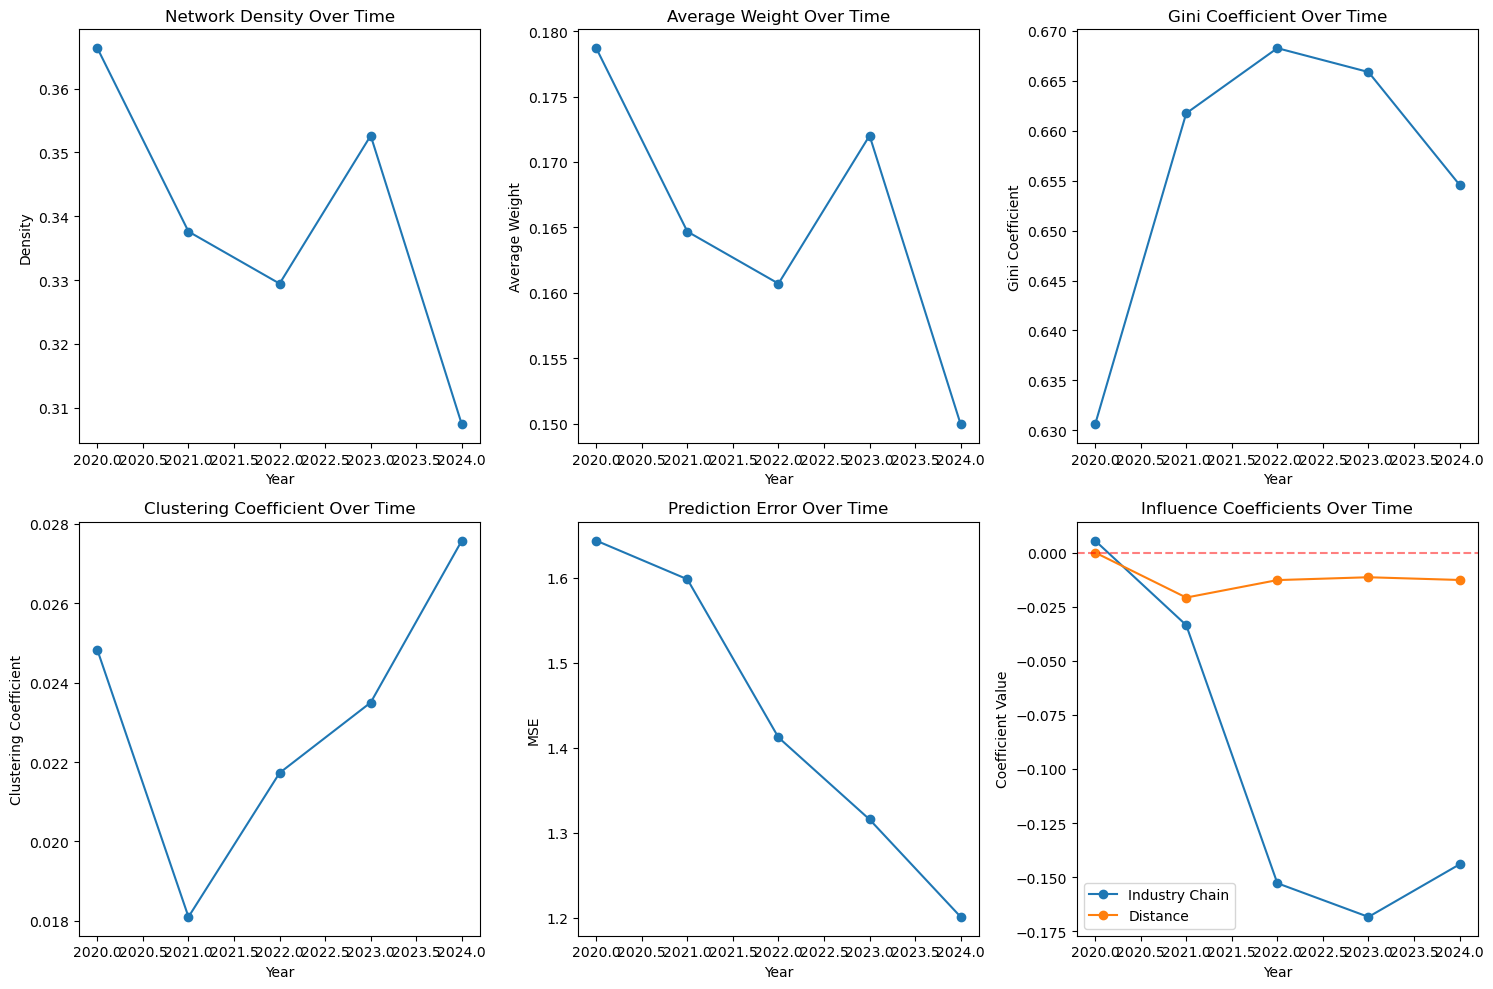

内卷程度分析图表已保存到 ./SFMNR_application_results/alliance_network/photovoltaic_industry_rollup_analysis.png

关键发现:
• 产业链相似性系数为负的年份:
  2021.0年: -0.0336
  2022.0年: -0.1528
  2023.0年: -0.1684
  2024.0年: -0.1441
  这可能表明同质化导致竞争加剧而合作减少，存在行业内卷表现
• 预测误差没有明显逐年增大的趋势
• 网络集中度没有明显逐年增加的趋势

分析完成！


In [49]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 导入之前定义的SMNR相关函数
from SMNR_func import SMNR, SMNR_predict, compute_xi, mat2vec_ix, get_zero_dummy, cross_validate_SMNR

def load_data(year):
    """
    加载指定年份的数据
    """
    # 加载战略联盟网络
    alliance_df = pd.read_csv(f"./SMNR_application_results/alliance_network/pdf_strategic_alliance_adjacency_{year}.csv", index_col=0)
    alliance_matrix = alliance_df.values.astype(float)
    
    # 加载产业链相似性矩阵
    industry_chain_df = pd.read_csv(f"./SMNR_application_results/alliance_network/industry_chain_similarity_{year}.csv", index_col=0)
    industry_chain_matrix = industry_chain_df.values.astype(float)
    
    # 加载地理位置距离相似性矩阵
    distance_df = pd.read_csv(f"./SMNR_application_results/alliance_network/distance_similarity_matrix_{year}.csv", index_col=0)
    distance_matrix = distance_df.values.astype(float)
    
    # 获取公司代码列表
    company_codes = alliance_df.index.tolist()
    
    return {
        'alliance': alliance_matrix,
        'industry_chain': industry_chain_matrix,
        'distance': distance_matrix,
        'company_codes': company_codes
    }

def prepare_relation_matrices(industry_chain_matrix, distance_matrix):
    """
    准备关系矩阵，只对产业链相似性矩阵进行零虚拟处理
    """
    # 对产业链相似性矩阵进行零虚拟处理
    industry_chain_adj, industry_chain_zero = get_zero_dummy(industry_chain_matrix)
    
    # 地理位置距离相似性矩阵直接使用，不进行零虚拟处理
    distance_adj = distance_matrix
    
    # 构建关系矩阵列表
    R_list = [industry_chain_adj, industry_chain_zero, distance_adj]
    
    return R_list

def ensure_symmetric(matrix):
    """
    确保矩阵是对称的（无向图）
    """
    return (matrix + matrix.T) / 2

def predict_missing_edges(alliance_matrix, R_list, year, verbose=False):
    """
    预测战略联盟网络中为零的位置（即缺失的边）
    对预测值进行四舍五入取整，确保结果为非负整数
    并确保预测矩阵是对称的
    """
    # 创建训练集（非零位置）
    train_adj = alliance_matrix.copy()
    
    # 计算组合矩阵
    xi = compute_xi(train_adj, directed=False, selfloops=False)
    
    # 使用交叉验证选择最优参数
    lambd_values = np.exp(np.linspace(np.log(0.1), np.log(20), 20))
    rho_values = np.exp(np.linspace(np.log(0.1), np.log(20), 20))
    
    if verbose:
        print(f"开始交叉验证选择最优参数...")
    
    cv_results = cross_validate_SMNR(
        R_list, train_adj, xi, 
        lambd_values=lambd_values,
        rho_values=rho_values,
        directed=False,
        selfloops=False,
        n_folds=2,
        apply_zero_dummy=False
    )
    
    best_lambda = cv_results['best_lambda']
    best_rho = cv_results['best_rho']
    
    if verbose:
        print(f"最优参数: lambda={best_lambda:.4f}, rho={best_rho:.4f}")
        print(f"最佳验证MSE: {cv_results['best_val_mse']:.4f}")
    
    # 使用最优参数训练最终模型
    model = SMNR(
        R_list, 
        train_adj, 
        xi=xi,
        lambd=best_lambda,
        rho=best_rho,
        directed=False,
        selfloops=False,
        verbose=verbose
    )
    
    # 预测整个网络
    pred_adj = SMNR_predict(
        train_adj,
        R_list,
        model['z'],
        directed=False,
        selfloops=False,
        method="exact"
    )

    # 确保预测矩阵是对称的
    pred_adj = ensure_symmetric(pred_adj)
    
    # 对预测值进行四舍五入取整，确保结果为非负整数
    # pred_adj_rounded = np.round(pred_adj)
    # pred_adj_rounded = np.maximum(pred_adj_rounded, 0)  # 确保非负
    
    # 确保预测矩阵是对称的
    # pred_adj_symmetric = ensure_symmetric(pred_adj_rounded)

    pred_adj = np.maximum(pred_adj, 0)  # 确保非负
    pred_adj_symmetric = ensure_symmetric(pred_adj)  # 确保预测矩阵是对称的
    
    # 只保留原始为零位置的预测值（即缺失边的预测）
    pred_missing = np.where(alliance_matrix == 0, pred_adj_symmetric, 0)
    
    # 计算预测误差
    # rmse = np.sqrt(mean_squared_error(alliance_matrix, pred_adj))
    # mae = mean_absolute_error(alliance_matrix, pred_adj)
    
    # 计算预测相关性（仅在已知边上，使用原始预测值，不取整）
    known_mask = alliance_matrix > 0
    pred_known = pred_adj[known_mask]  # 使用原始预测值计算误差
    true_known = alliance_matrix[known_mask]
    rmse = np.sqrt(mean_squared_error(true_known, pred_known))
    mae = mean_absolute_error(true_known, pred_known)
    # 计算皮尔森相关性
    if len(true_known) > 1:  # 确保有足够的数据点计算相关性
        correlation, p_value = pearsonr(true_known, pred_known)
    else:
        correlation, p_value = 0, 1
    
    # 创建完整预测网络（已知边保留原值，未知边使用取整后的预测值）
    full_pred_network = np.where(alliance_matrix > 0, alliance_matrix, pred_missing)
    
    # 确保最终预测矩阵是对称的
    full_pred_network = ensure_symmetric(full_pred_network)
    
    return {
        'predicted_network': full_pred_network,
        'predicted_missing': pred_missing,
        'model': model,
        'rmse': rmse,
        'mae': mae,
        'correlation': correlation,
        'correlation_p_value': p_value,
        'year': year,
        'best_lambda': best_lambda,
        'best_rho': best_rho
    }

def calculate_network_density(adj_matrix):
    """
    计算网络密度
    """
    n = adj_matrix.shape[0]
    max_possible_edges = n * (n - 1) / 2  # 无向图的最大边数
    actual_edges = np.sum(adj_matrix)
    density = actual_edges / max_possible_edges
    return density

def calculate_average_weight(adj_matrix):
    """
    计算平均权重
    """
    # nonzero_weights = adj_matrix[adj_matrix > 0]
    # if len(nonzero_weights) > 0:
    #     return np.mean(nonzero_weights)
    # return 0
    return np.sum(adj_matrix) / (adj_matrix.shape[0] * adj_matrix.shape[1])

def calculate_gini_coefficient(adj_matrix):
    """
    计算基尼系数
    """
    # 获取所有权重（只考虑非零值）
    # weights = adj_matrix[adj_matrix > 0].flatten()
    weights = adj_matrix.flatten()
    if len(weights) == 0:
        return 0
    
    # 计算基尼系数
    weights_sorted = np.sort(weights)
    n = len(weights_sorted)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * weights_sorted)) / (n * np.sum(weights_sorted))

def calculate_clustering_coefficient(adj_matrix):
    """
    计算聚类系数
    """
    # 创建图对象
    G = nx.from_numpy_array(adj_matrix)
    
    # 计算平均聚类系数
    if len(G) > 0:
        return nx.average_clustering(G, weight='weight')
    return 0

def analyze_industry_rollup(years_data):
    """
    分析行业内卷程度
    """
    results = []
    
    for year_data in years_data:
        year = year_data['year']
        alliance_matrix = year_data['alliance_matrix']
        pred_network = year_data['predicted_network']
        model = year_data['model']
        
        # 计算各项指标
        density_origin = calculate_network_density(alliance_matrix)
        avg_weight_origin = calculate_average_weight(alliance_matrix)
        gini_coeff_origin = calculate_gini_coefficient(alliance_matrix)
        clustering_origin = calculate_clustering_coefficient(alliance_matrix)
        
        density_pred = calculate_network_density(pred_network)
        avg_weight_pred = calculate_average_weight(pred_network)
        gini_coeff_pred = calculate_gini_coefficient(pred_network)
        clustering_pred = calculate_clustering_coefficient(pred_network)
        prediction_error = year_data['rmse']

        # 获取影响系数
        # R_list的顺序是 [industry_chain_adj, industry_chain_zero, distance_adj]
        industry_chain_coef = model['z'][0]  # 产业链相似性的主要系数
        distance_coef = model['z'][2]        # 地理位置距离相似性的主要系数
        industry_chain_pvalue = model['p_values'][0]
        distance_pvalue = model['p_values'][2]
        
        results.append({
            'year': year,
            'density_origin': density_origin,
            'avg_weight_origin': avg_weight_origin,
            'gini_coeff_origin': gini_coeff_origin,
            'clustering_origin': clustering_origin,
            'density_pred': density_pred,
            'avg_weight_pred': avg_weight_pred,
            'gini_coeff_pred': gini_coeff_pred,
            'clustering_pred': clustering_pred,
            'prediction_error': prediction_error,
            'prediction_r': year_data['correlation'],
            'prediction_r_p_value': year_data['correlation_p_value'],
            'industry_chain_coef': industry_chain_coef,
            'industry_chain_pvalue': industry_chain_pvalue,
            'distance_coef': distance_coef,
            'distance_pvalue': distance_pvalue
        })
    
    return pd.DataFrame(results)

def plot_rollup_analysis(rollup_df):
    """
    绘制行业内卷分析结果
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 网络密度变化
    axes[0, 0].plot(rollup_df['year'], rollup_df['density_pred'], 'o-')
    axes[0, 0].set_title('Network Density Over Time')
    axes[0, 0].set_xlabel('Year')
    axes[0, 0].set_ylabel('Density')
    
    # 平均权重变化
    axes[0, 1].plot(rollup_df['year'], rollup_df['avg_weight_pred'], 'o-')
    axes[0, 1].set_title('Average Weight Over Time')
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Average Weight')
    
    # 基尼系数变化
    axes[0, 2].plot(rollup_df['year'], rollup_df['gini_coeff_pred'], 'o-')
    axes[0, 2].set_title('Gini Coefficient Over Time')
    axes[0, 2].set_xlabel('Year')
    axes[0, 2].set_ylabel('Gini Coefficient')
    
    # 聚类系数变化
    axes[1, 0].plot(rollup_df['year'], rollup_df['clustering_pred'], 'o-')
    axes[1, 0].set_title('Clustering Coefficient Over Time')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Clustering Coefficient')
    
    # 预测误差变化
    axes[1, 1].plot(rollup_df['year'], rollup_df['prediction_error'], 'o-')
    axes[1, 1].set_title('Prediction Error Over Time')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('MSE')
    
    # 影响系数变化
    axes[1, 2].plot(rollup_df['year'], rollup_df['industry_chain_coef'], 'o-', label='Industry Chain')
    axes[1, 2].plot(rollup_df['year'], rollup_df['distance_coef'], 'o-', label='Distance')
    axes[1, 2].set_title('Influence Coefficients Over Time')
    axes[1, 2].set_xlabel('Year')
    axes[1, 2].set_ylabel('Coefficient Value')
    axes[1, 2].legend()
    axes[1, 2].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('./SMNR_application_results/alliance_network/photovoltaic_industry_rollup_analysis.png', dpi=300)
    plt.show()

def check_symmetry(matrix, tol=1e-10):
    """
    检查矩阵是否对称
    """
    return np.allclose(matrix, matrix.T, atol=tol)

def main():
    """
    主函数：执行完整的分析流程
    """
    years = [2020, 2021, 2022, 2023, 2024]
    years_data = []
    
    print("开始中国光伏行业战略联盟网络预测与内卷程度分析...")
    
    for year in years:
        print(f"\n处理 {year} 年数据...")
        
        try:
            # 加载数据
            data = load_data(year)
            alliance_matrix = data['alliance']
            industry_chain_matrix = data['industry_chain']
            distance_matrix = data['distance']
            
            # 检查原始矩阵是否对称
            if not check_symmetry(alliance_matrix):
                print(f"  警告：{year}年战略联盟网络矩阵不是对称的，将进行对称化处理")
                alliance_matrix = ensure_symmetric(alliance_matrix)
            
            # 准备关系矩阵
            R_list = prepare_relation_matrices(industry_chain_matrix, distance_matrix)
            
            # 预测缺失边
            results = predict_missing_edges(alliance_matrix, R_list, year, verbose=True)
            
            # 检查预测矩阵是否对称
            if not check_symmetry(results['predicted_network']):
                print(f"  警告：{year}年预测矩阵不是对称的，将进行对称化处理")
                results['predicted_network'] = ensure_symmetric(results['predicted_network'])
                results['predicted_missing'] = np.where(alliance_matrix == 0, results['predicted_network'], 0)
            
            # 保存结果
            years_data.append({
                'year': year,
                'alliance_matrix': alliance_matrix,
                'predicted_network': results['predicted_network'],
                'model': results['model'],
                'rmse': results['rmse'],
                'mae': results['mae'],
                'correlation': results['correlation'],
                'correlation_p_value': results['correlation_p_value'],
                'best_lambda': results['best_lambda'],
                'best_rho': results['best_rho']
            })
            
            print(f"  {year} 年预测完成，RMSE: {results['rmse']:.4f}, MAE: {results['mae']:.4f}")
            print(f"  皮尔森相关性: {results['correlation']:.4f} (p-value: {results['correlation_p_value']:.4f})")
            print(f"  最优参数: lambda={results['best_lambda']:.4f}, rho={results['best_rho']:.4f}")
            
            # 保存预测结果
            pred_df = pd.DataFrame(
                results['predicted_network'],
                index=data['company_codes'],
                columns=data['company_codes']
            )
            pred_df.to_csv(f'./SMNR_application_results/alliance_network/predicted_alliance_network_{year}.csv')
            print(f"  预测结果已保存到 ./SMNR_application_results/alliance_network/predicted_alliance_network_{year}.csv")
            
            # 保存缺失边的预测结果
            missing_pred_df = pd.DataFrame(
                results['predicted_missing'],
                index=data['company_codes'],
                columns=data['company_codes']
            )
            missing_pred_df.to_csv(f'./SMNR_application_results/alliance_network/predicted_missing_edges_{year}.csv')
            print(f"  缺失边预测结果已保存到 ./SMNR_application_results/alliance_network/predicted_missing_edges_{year}.csv")
            
            # 检查最终矩阵是否对称
            if check_symmetry(results['predicted_network']):
                print(f"  确认：{year}年预测矩阵是对称的")
            else:
                print(f"  警告：{year}年预测矩阵仍然不对称")
            
        except Exception as e:
            print(f"处理 {year} 年数据时出错: {str(e)}")
            continue
    
    # 分析行业内卷程度
    print("\n分析行业内卷程度...")
    rollup_df = analyze_industry_rollup(years_data)
    rollup_df.to_csv('./SMNR_application_results/alliance_network/industry_rollup_analysis.csv', index=False)
    print("内卷程度分析结果已保存到 ./SMNR_application_results/alliance_network/industry_rollup_analysis.csv")
    
    # 绘制分析结果
    plot_rollup_analysis(rollup_df)
    print("内卷程度分析图表已保存到 ./SMNR_application_results/alliance_network/photovoltaic_industry_rollup_analysis.png")
    
    # 输出关键发现
    print("\n关键发现:")
    print("=" * 50)
    
    # 检查产业链相似性系数是否为负
    negative_industry_coef = rollup_df[rollup_df['industry_chain_coef'] < 0]
    if len(negative_industry_coef) > 0:
        print("• 产业链相似性系数为负的年份:")
        for _, row in negative_industry_coef.iterrows():
            print(f"  {row['year']}年: {row['industry_chain_coef']:.4f}")
        print("  这可能表明同质化导致竞争加剧而合作减少，存在行业内卷表现")
    else:
        print("• 所有年份的产业链相似性系数均为正")
    
    # 检查预测误差趋势
    error_increase = all(rollup_df['prediction_error'].diff().dropna() > 0)
    if error_increase:
        print("• 预测误差逐年增大")
        print("  可能说明联盟形成受到更多非经济因素影响，导致模型难以捕捉规律")
        print("  这表明存在比较大的行业内卷表现")
    else:
        print("• 预测误差没有明显逐年增大的趋势")
    
    # 检查网络集中度趋势
    gini_increase = all(rollup_df['gini_coeff_pred'].diff().dropna() > 0)
    if gini_increase:
        print("• 网络集中度（基尼系数）逐年增加")
        print("  表明联盟越来越集中在少数企业，马太效应加剧")
        print("  这是行业内卷的表现之一")
    else:
        print("• 网络集中度没有明显逐年增加的趋势")
    
    print("=" * 50)
    print("\n分析完成！")

if __name__ == "__main__":
    main()